# Loan Approval Study: KNN and Naive Bayes for Classification, KNN for Regression

## Phase 1: Business Understanding and Problem Definition

### Overview

This notebook applies two instance-based and probabilistic learning algorithms, K-Nearest
Neighbors and Gaussian Naive Bayes, to the loan approval dataset. Two distinct predictive
tasks are addressed using the same source data.

The first task is binary classification: predicting loan_status, whether an application is
Approved or Rejected, using K-Nearest Neighbors Classifier and Gaussian Naive Bayes
Classifier. For this task, loan_amount is deliberately retained as an input feature. In a
real underwriting workflow the requested or sanctioned amount is known at the time an
approval decision is evaluated, and including it produces a more realistic and typically
higher-performing classification model, since the requested amount relative to income and
assets is one of the strongest signals of approval likelihood.

The second task is regression: predicting loan_amount, a continuous quantity, using
K-Nearest Neighbors Regressor. Gaussian Naive Bayes is a probabilistic classification
algorithm built on Bayes theorem and class-conditional likelihood estimation; it has no
standard formulation as a regression algorithm and is therefore not applied to the
regression task. For the regression task, loan_status is excluded from the feature set, for
the same target leakage reasoning documented in the companion regression project: the
approval decision is not available at the point where a loan amount recommendation is
required.

### Why K-Nearest Neighbors

K-Nearest Neighbors is a non-parametric, instance-based algorithm that makes predictions by
identifying the k most similar historical records to a new observation, based on a distance
metric computed over the feature space, and aggregating their outcomes: majority vote for
classification, and mean or weighted mean for regression. Its performance is highly
sensitive to feature scaling, since distance calculations are dominated by features with
larger numerical ranges unless all features are standardized to a comparable scale.

### Why Gaussian Naive Bayes

Gaussian Naive Bayes assumes that each numerical feature, conditional on the class label,
follows a normal distribution, and that features are conditionally independent given the
class. Despite this simplifying independence assumption rarely holding exactly in practice,
Naive Bayes classifiers are computationally efficient, require comparatively little training
data, and frequently perform competitively as a baseline against more complex classifiers.

### Dataset Description

The dataset, loan_approval_dataset.csv, contains 4269 loan applications with no missing
values across any of its 13 original columns. It includes applicant demographic and
financial attributes, requested loan terms, a credit bureau score, asset valuations, and the
historical approval decision. The dataset is already clean prior to any transformation in
this notebook, aside from minor whitespace normalization required in its string columns and
the standard modeling transformations, encoding and scaling, applied below.

## Phase 2: Environment Setup and Data Ingestion

This phase imports all required libraries and loads the raw dataset using dynamic path
resolution, so that the notebook executes correctly whether run from within a notebooks
directory, looking one level up into data/raw, or from the project root, looking directly
into data/raw.

In [1]:
import os
import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

candidate_paths = [
    os.path.join("..", "data", "raw", "loan_approval_dataset.csv"),
    os.path.join("data", "raw", "loan_approval_dataset.csv"),
]

DATA_PATH = None
for candidate in candidate_paths:
    if os.path.exists(candidate):
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate loan_approval_dataset.csv in ../data/raw/ or data/raw/. "
        "Please verify the dataset location."
    )

print("Dataset located at:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.columns = [column.strip() for column in df.columns]

print("Dataset dimensions (rows, columns):", df.shape)
print()
print("First 5 rows of the raw dataset:")
display(df.head())
print()
print("Structural summary of the raw dataset:")
df.info()

Dataset located at: ..\data\raw\loan_approval_dataset.csv
Dataset dimensions (rows, columns): (4269, 13)

First 5 rows of the raw dataset:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Structural summary of the raw dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


## Phase 3: Data Quality Assessment and Cleaning

Missing values, exact duplicate rows, and leading or trailing whitespace in string valued
columns are checked and corrected in this phase. The loan_id column is a sequential
identifier with no predictive value and is dropped.

In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print()

duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed. New shape:", df.shape)

string_columns = df.select_dtypes(include="object").columns.tolist()
for column in string_columns:
    df[column] = df[column].astype(str).str.strip()

print()
print("Categorical column unique values after whitespace normalization:")
for column in string_columns:
    print(column, "->", df[column].unique().tolist())

if "loan_id" in df.columns:
    df = df.drop(columns=["loan_id"])
    print()
    print("Dropped non-predictive identifier column: loan_id")

print()
print("Cleaned column schema:")
print(df.dtypes)

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Number of exact duplicate rows: 0

Categorical column unique values after whitespace normalization:
education -> ['Graduate', 'Not Graduate']
self_employed -> ['No', 'Yes']
loan_status -> ['Approved', 'Rejected']

Dropped non-predictive identifier column: loan_id

Cleaned column schema:
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercia

## Phase 4: Outlier Detection and Treatment

K-Nearest Neighbors is a distance-based algorithm and is sensitive to extreme values in
numerical features, since a single outlier can dominate distance calculations even after
scaling. The Interquartile Range method is applied to every numerical predictor: values
falling more than 1.5 times the interquartile range beyond the first or third quartile are
capped, winsorized, to the corresponding boundary rather than removed, preserving sample
size while limiting the leverage of extreme observations.

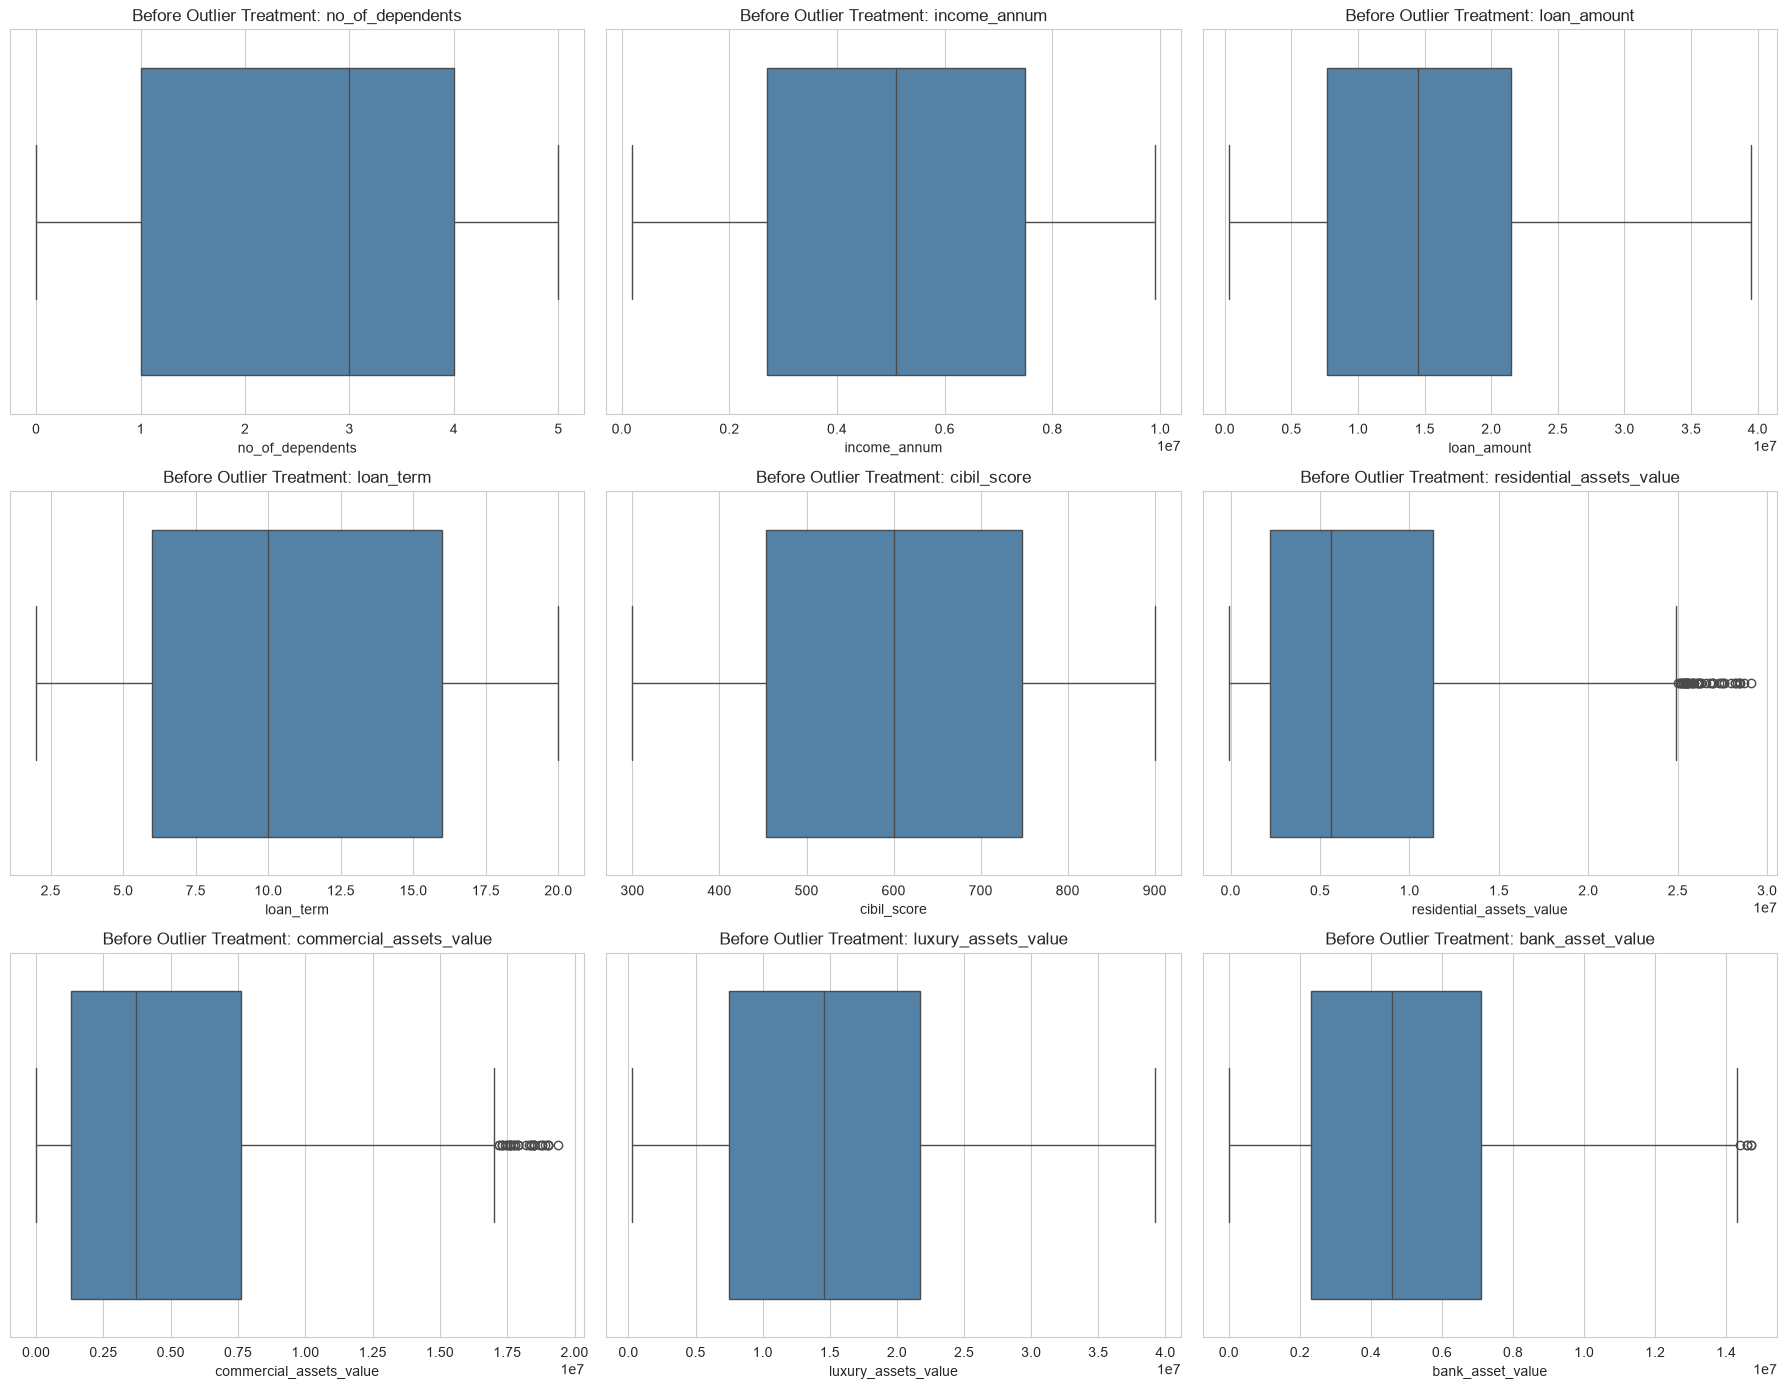

Outlier counts detected per column, prior to capping:
no_of_dependents: 0 outlier observations capped
income_annum: 0 outlier observations capped
loan_amount: 0 outlier observations capped
loan_term: 0 outlier observations capped
cibil_score: 0 outlier observations capped
residential_assets_value: 52 outlier observations capped
commercial_assets_value: 37 outlier observations capped
luxury_assets_value: 0 outlier observations capped
bank_asset_value: 5 outlier observations capped


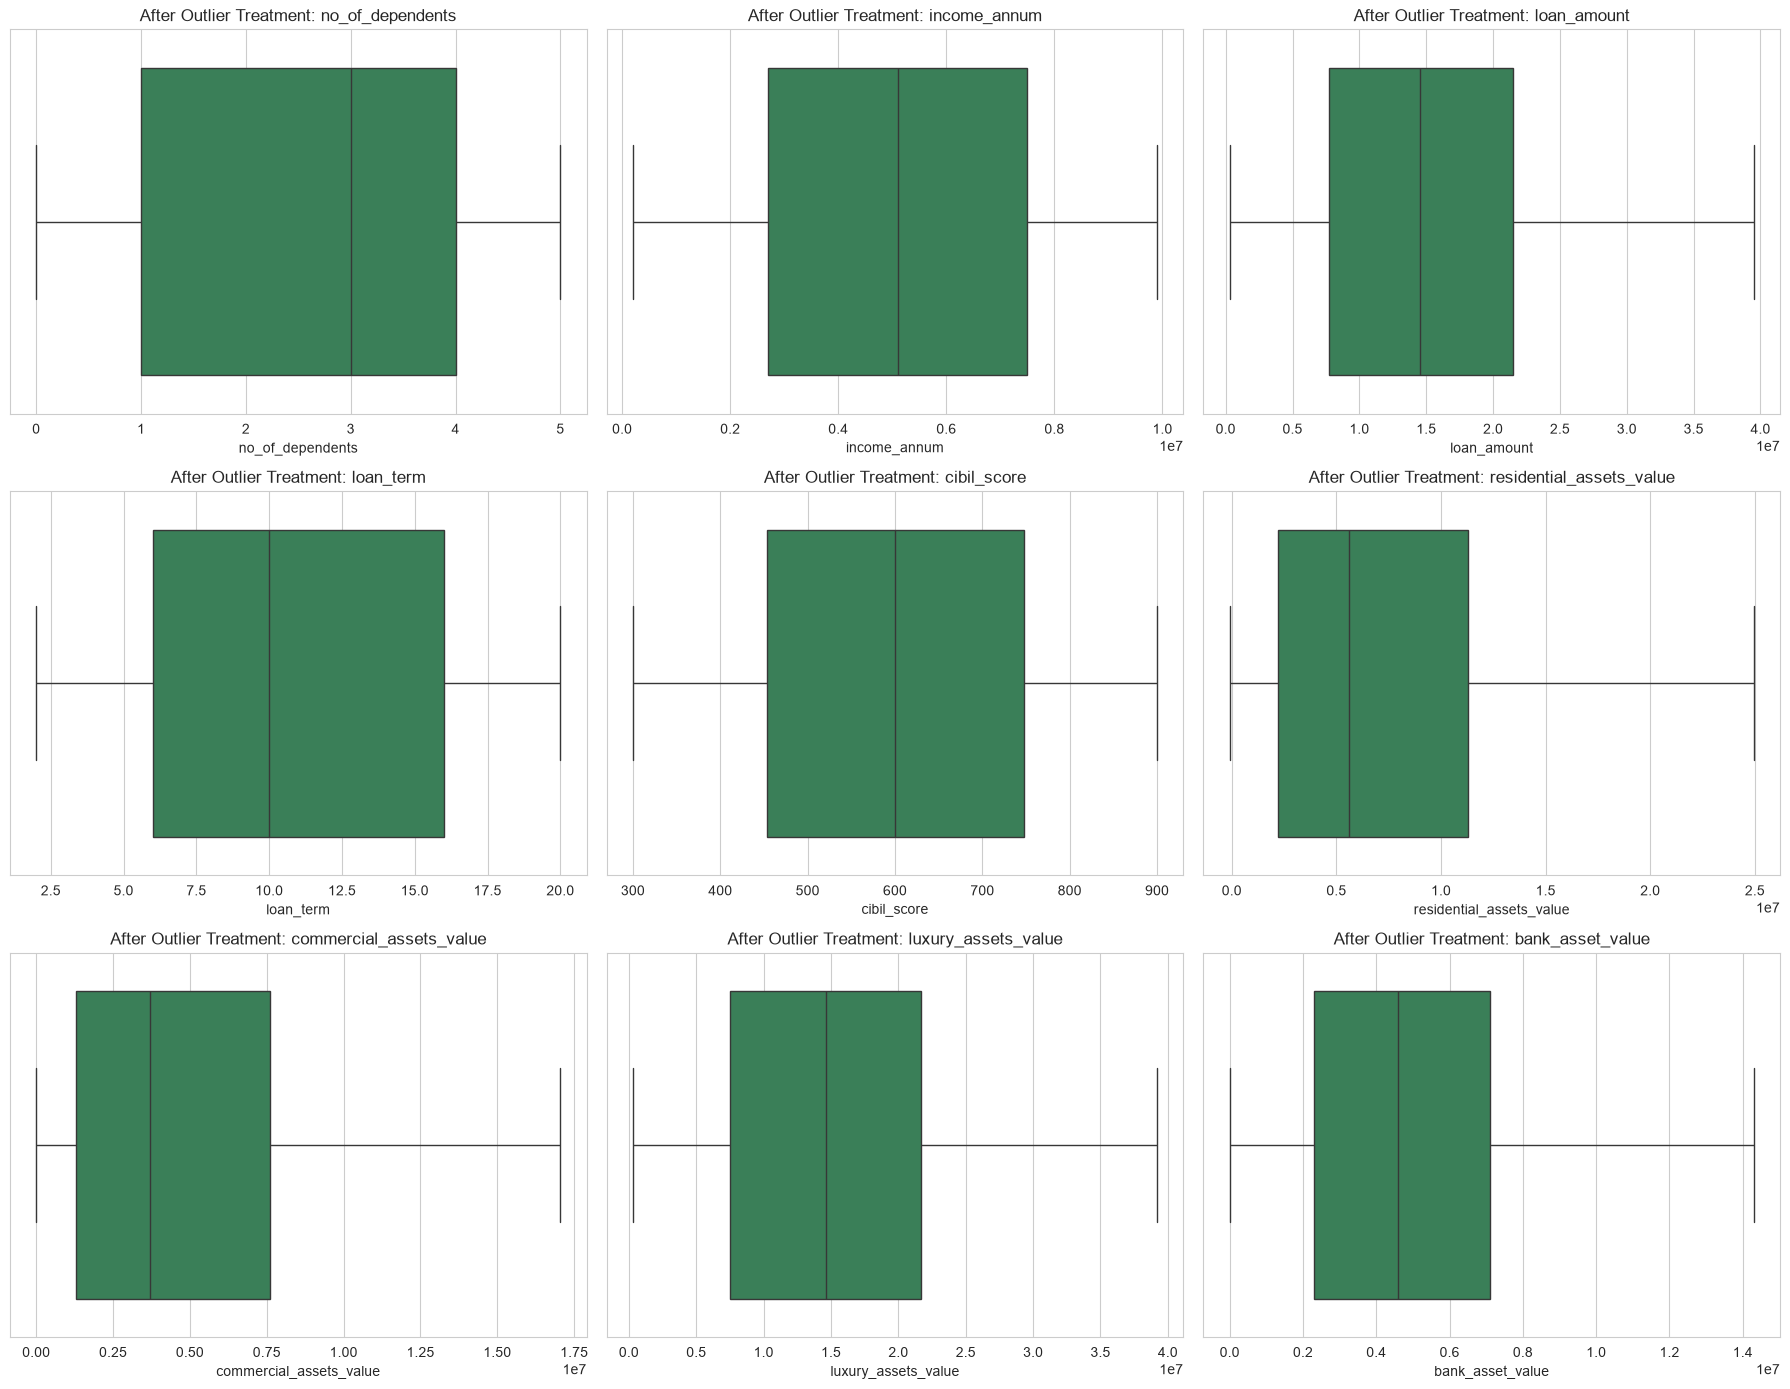

In [3]:
numerical_columns = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for index, column in enumerate(numerical_columns):
    sns.boxplot(x=df[column], ax=axes[index], color="steelblue")
    axes[index].set_title(f"Before Outlier Treatment: {column}")
plt.tight_layout()
plt.show()

outlier_summary = {}
for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_detected = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary[column] = outliers_detected

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

print("Outlier counts detected per column, prior to capping:")
for column, count in outlier_summary.items():
    print(f"{column}: {count} outlier observations capped")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for index, column in enumerate(numerical_columns):
    sns.boxplot(x=df[column], ax=axes[index], color="seagreen")
    axes[index].set_title(f"After Outlier Treatment: {column}")
plt.tight_layout()
plt.show()

## Phase 5: Exploratory Data Analysis

This phase examines the distribution of both target variables used in this notebook,
loan_status for the classification task and loan_amount for the regression task, along with
their relationships to key predictors. Class balance is quantified explicitly for
loan_status, since imbalance affects the interpretation of classification accuracy.

Class distribution of loan_status:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Class distribution of loan_status (proportions):
loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64


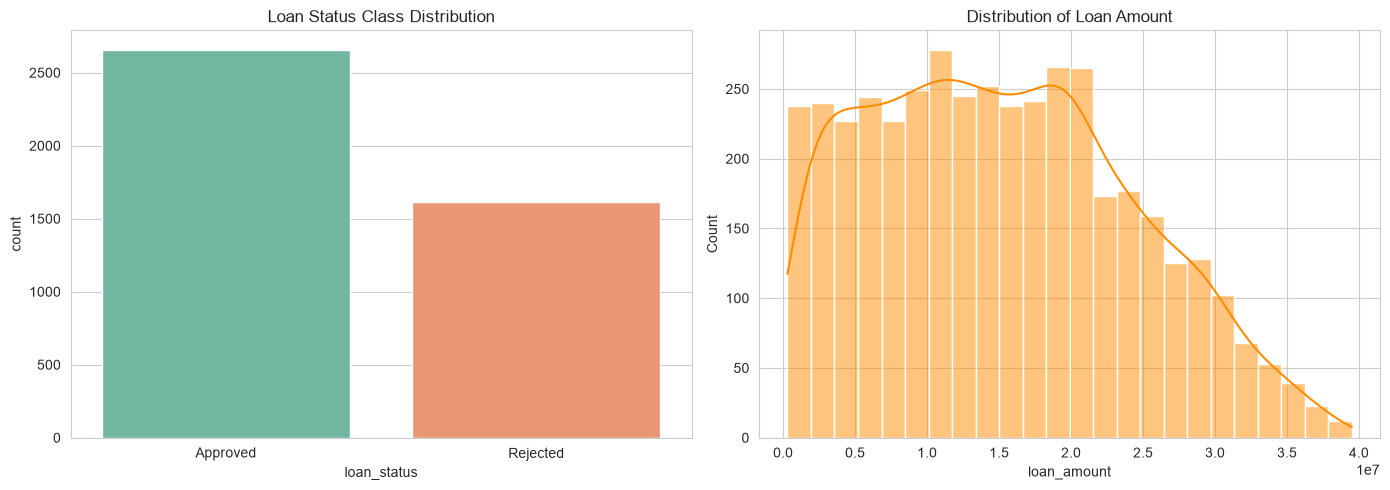


Summary statistics for all numerical features:


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.454861e+06,4.964289e+06,1.512631e+07,4.976341e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.452442e+06,4.363080e+06,9.103754e+06,3.249159e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.495000e+07,1.705000e+07,3.920000e+07,1.430000e+07


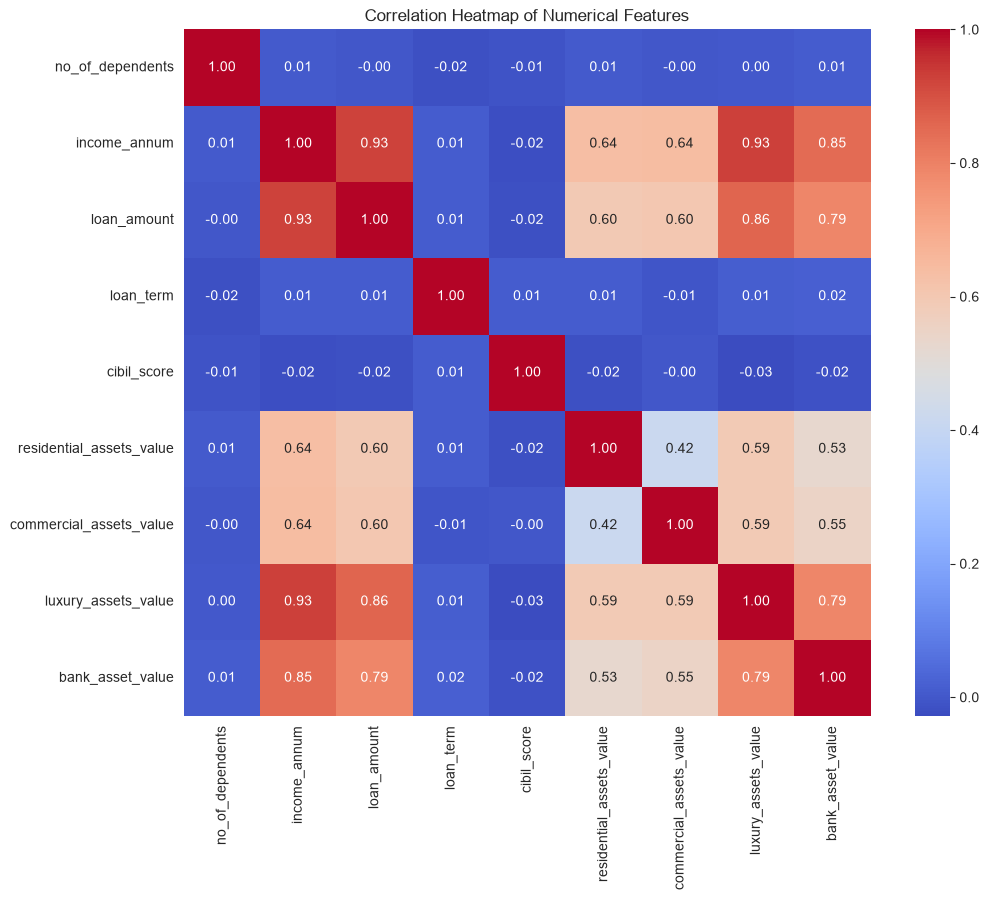

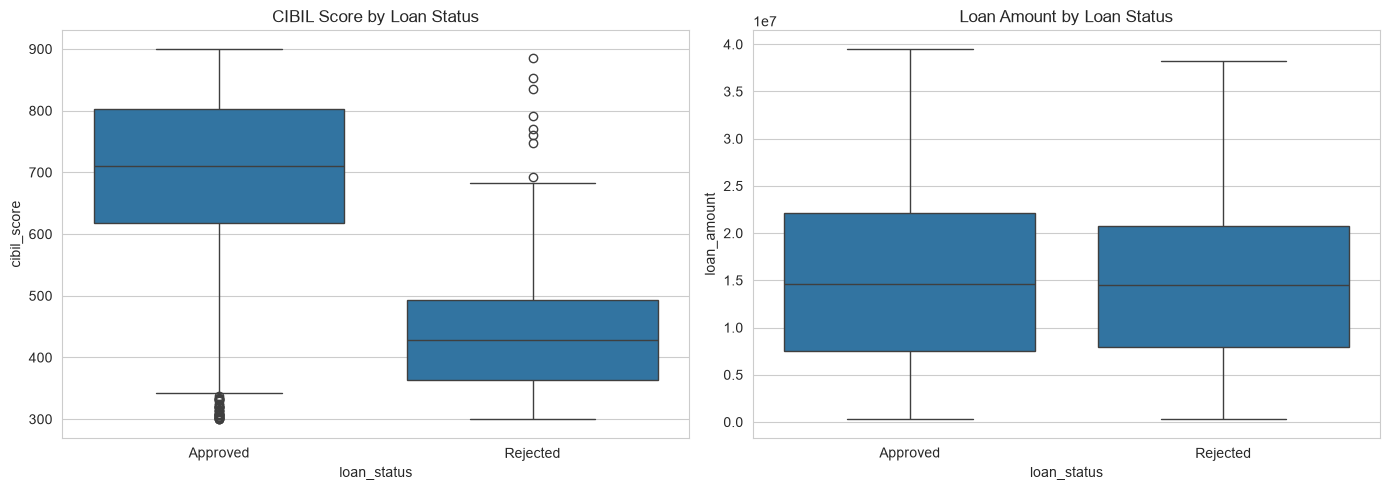

In [4]:
print("Class distribution of loan_status:")
print(df["loan_status"].value_counts())
print()
print("Class distribution of loan_status (proportions):")
print(df["loan_status"].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="loan_status", ax=axes[0], palette="Set2")
axes[0].set_title("Loan Status Class Distribution")
sns.histplot(df["loan_amount"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Loan Amount")
plt.tight_layout()
plt.show()

print()
print("Summary statistics for all numerical features:")
display(df.describe())

correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="loan_status", y="cibil_score", ax=axes[0])
axes[0].set_title("CIBIL Score by Loan Status")
sns.boxplot(data=df, x="loan_status", y="loan_amount", ax=axes[1])
axes[1].set_title("Loan Amount by Loan Status")
plt.tight_layout()
plt.show()

## Phase 6: Encoding and Feature Preparation

Categorical predictors, education and self_employed, are transformed using One-Hot Encoding
via pandas.get_dummies with drop_first equal to True. The loan_status target variable used
for classification is transformed into a binary integer using LabelEncoder, with Approved
mapped to 1 and Rejected mapped to 0. Two separate feature matrices are constructed: one for
the classification task, which retains loan_amount as a predictor, and one for the
regression task, which excludes loan_status entirely to avoid target leakage, consistent
with the business justification given in Phase 1.

In [5]:
categorical_columns = ["education", "self_employed"]

label_encoder = LabelEncoder()
df["loan_status_encoded"] = label_encoder.fit_transform(df["loan_status"])

print("Label encoding mapping for loan_status:")
for class_label, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {class_label} -> {encoded_value}")

# ---- Classification feature matrix: loan_amount retained as a predictor ----
classification_features_source = df.drop(columns=["loan_status", "loan_status_encoded"])
X_classification = pd.get_dummies(
    classification_features_source, columns=categorical_columns, drop_first=True
)
y_classification = df["loan_status_encoded"].copy()
classification_feature_columns = X_classification.columns.tolist()

print()
print("Classification feature matrix shape:", X_classification.shape)
print("Classification feature columns:", classification_feature_columns)

# ---- Regression feature matrix: loan_status excluded to avoid target leakage ----
regression_features_source = df.drop(columns=["loan_status", "loan_status_encoded", "loan_amount"])
X_regression = pd.get_dummies(
    regression_features_source, columns=categorical_columns, drop_first=True
)
y_regression = df["loan_amount"].copy()
regression_feature_columns = X_regression.columns.tolist()

print()
print("Regression feature matrix shape:", X_regression.shape)
print("Regression feature columns:", regression_feature_columns)

Label encoding mapping for loan_status:
  Approved -> 0
  Rejected -> 1

Classification feature matrix shape: (4269, 11)
Classification feature columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_Not Graduate', 'self_employed_Yes']

Regression feature matrix shape: (4269, 10)
Regression feature columns: ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_Not Graduate', 'self_employed_Yes']


## Phase 7: Classification Task, Train and Test Split, and Feature Scaling

The classification feature matrix and target vector are split into an 80 percent training
set and a 20 percent testing set, using stratified sampling on loan_status to preserve the
class proportions between the two partitions, and a fixed random_state of 42 for
reproducibility. StandardScaler is fit exclusively on the training partition and then
applied to both partitions, since K-Nearest Neighbors distance calculations require
comparably scaled features to prevent large-magnitude columns, such as asset values, from
dominating the distance metric over small-magnitude columns, such as the number of
dependents.

In [6]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_classification,
)

print("Classification training set shape:", X_train_cls.shape)
print("Classification testing set shape:", X_test_cls.shape)

classification_scaler = StandardScaler()
X_train_cls_scaled = classification_scaler.fit_transform(X_train_cls)
X_test_cls_scaled = classification_scaler.transform(X_test_cls)

X_train_cls_scaled = pd.DataFrame(
    X_train_cls_scaled, columns=classification_feature_columns, index=X_train_cls.index
)
X_test_cls_scaled = pd.DataFrame(
    X_test_cls_scaled, columns=classification_feature_columns, index=X_test_cls.index
)

print()
print("Feature scaling completed for the classification task.")

Classification training set shape: (3415, 11)
Classification testing set shape: (854, 11)

Feature scaling completed for the classification task.


## Phase 8: Classification Model Training, K-Nearest Neighbors and Gaussian Naive Bayes

K-Nearest Neighbors Classifier is tuned using GridSearchCV with 5-fold cross validation,
searching over the number of neighbors, the distance weighting scheme, and the distance
metric, scoring on accuracy. Gaussian Naive Bayes has no equivalent hyperparameter grid in
its standard formulation and is fit directly on the scaled training data, since it estimates
class-conditional means and variances directly from the training sample.

In [7]:
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
knn_grid_search.fit(X_train_cls_scaled, y_train_cls)

best_knn_classifier = knn_grid_search.best_estimator_
print("Best KNN Classifier parameters:", knn_grid_search.best_params_)
print("Best cross validation accuracy:", knn_grid_search.best_score_)

naive_bayes_classifier = GaussianNB()
naive_bayes_classifier.fit(X_train_cls_scaled, y_train_cls)
print()
print("Gaussian Naive Bayes classifier training completed.")

Best KNN Classifier parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best cross validation accuracy: 0.9127379209370424

Gaussian Naive Bayes classifier training completed.


## Phase 9: Classification Evaluation and Comparison

Accuracy alone can be misleading when class proportions are not perfectly balanced.
Precision, recall, F1-score, and ROC-AUC are computed alongside accuracy for both K-Nearest
Neighbors and Gaussian Naive Bayes, and confusion matrices are visualized to inspect the
distribution of correct and incorrect predictions across both classes.

Model: KNN Classifier
  Accuracy  : 0.9333
  Precision : 0.9346
  Recall    : 0.8854
  F1 Score  : 0.9094
  ROC AUC   : 0.9775

              precision    recall  f1-score   support

    Approved       0.93      0.96      0.95       531
    Rejected       0.93      0.89      0.91       323

    accuracy                           0.93       854
   macro avg       0.93      0.92      0.93       854
weighted avg       0.93      0.93      0.93       854


Model: Gaussian Naive Bayes
  Accuracy  : 0.9461
  Precision : 0.9315
  Recall    : 0.9257
  F1 Score  : 0.9286
  ROC AUC   : 0.9751

              precision    recall  f1-score   support

    Approved       0.95      0.96      0.96       531
    Rejected       0.93      0.93      0.93       323

    accuracy                           0.95       854
   macro avg       0.94      0.94      0.94       854
weighted avg       0.95      0.95      0.95       854




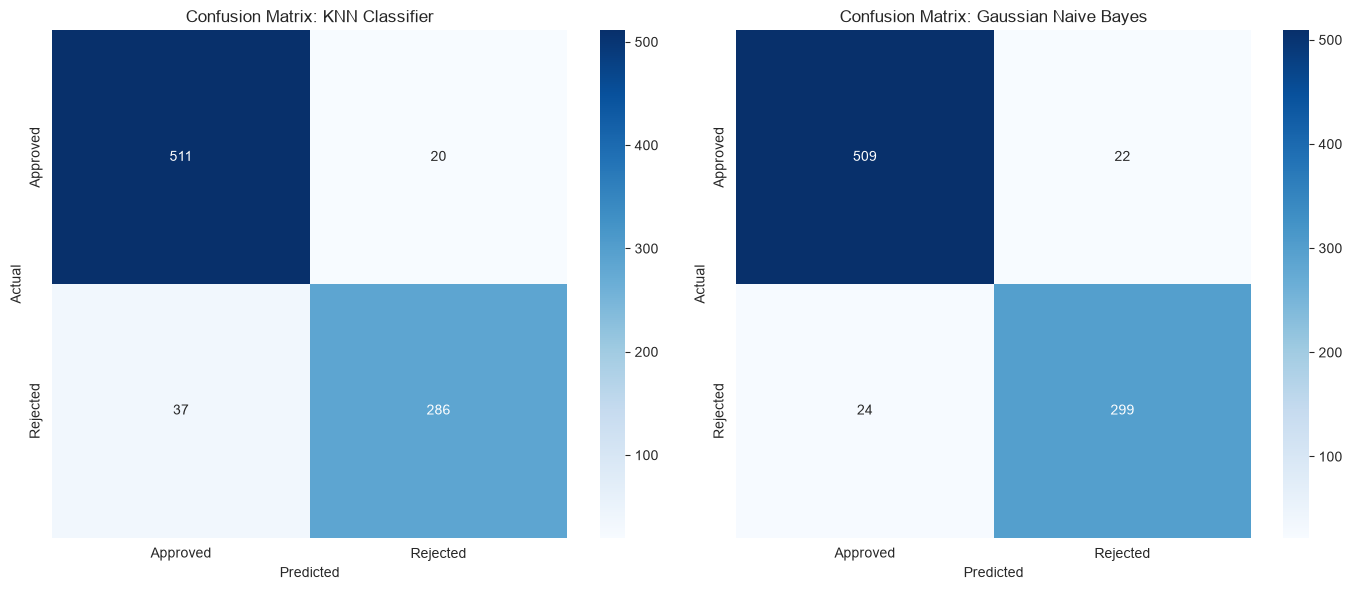

Classification model comparison table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gaussian Naive Bayes,0.946136,0.931464,0.925697,0.928571,0.975104
1,KNN Classifier,0.933255,0.934641,0.885449,0.909380,0.977512


In [8]:
classification_models = {
    "KNN Classifier": best_knn_classifier,
    "Gaussian Naive Bayes": naive_bayes_classifier,
}

classification_results = []

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for index, (model_name, model) in enumerate(classification_models.items()):
    predictions = model.predict(X_test_cls_scaled)
    probabilities = model.predict_proba(X_test_cls_scaled)[:, 1]

    accuracy = accuracy_score(y_test_cls, predictions)
    precision = precision_score(y_test_cls, predictions)
    recall = recall_score(y_test_cls, predictions)
    f1 = f1_score(y_test_cls, predictions)
    roc_auc = roc_auc_score(y_test_cls, probabilities)

    classification_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc,
        }
    )

    print(f"Model: {model_name}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC AUC   : {roc_auc:.4f}")
    print()
    print(classification_report(y_test_cls, predictions, target_names=label_encoder.classes_))
    print()

    confusion_mat = confusion_matrix(y_test_cls, predictions)
    sns.heatmap(
        confusion_mat,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[index],
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    axes[index].set_title(f"Confusion Matrix: {model_name}")
    axes[index].set_xlabel("Predicted")
    axes[index].set_ylabel("Actual")

plt.tight_layout()
plt.show()

classification_comparison_df = pd.DataFrame(classification_results).sort_values(
    by="Accuracy", ascending=False
).reset_index(drop=True)
print("Classification model comparison table:")
display(classification_comparison_df)

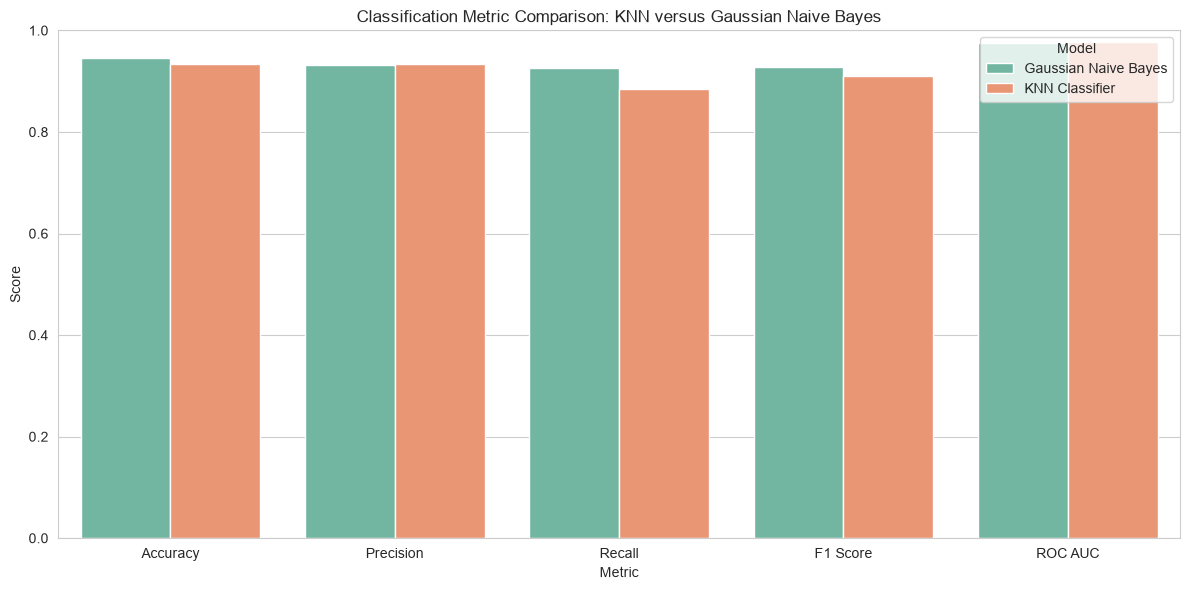

Best performing classification model based on test set accuracy: Gaussian Naive Bayes


In [9]:
comparison_melted = classification_comparison_df.melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Classification Metric Comparison: KNN versus Gaussian Naive Bayes")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

best_classification_model_name = classification_comparison_df.iloc[0]["Model"]
print(f"Best performing classification model based on test set accuracy: {best_classification_model_name}")

## Phase 10: Regression Task, Train and Test Split, and Feature Scaling

The regression feature matrix, which excludes loan_status, is split into an 80 percent
training set and a 20 percent testing set using a fixed random_state of 42. Feature scaling
through StandardScaler is applied identically to the classification task, fit exclusively on
the training partition, since K-Nearest Neighbors Regressor is equally sensitive to feature
scale as its classification counterpart.

In [10]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, test_size=0.20, random_state=RANDOM_STATE
)

print("Regression training set shape:", X_train_reg.shape)
print("Regression testing set shape:", X_test_reg.shape)

regression_scaler = StandardScaler()
X_train_reg_scaled = regression_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = regression_scaler.transform(X_test_reg)

X_train_reg_scaled = pd.DataFrame(
    X_train_reg_scaled, columns=regression_feature_columns, index=X_train_reg.index
)
X_test_reg_scaled = pd.DataFrame(
    X_test_reg_scaled, columns=regression_feature_columns, index=X_test_reg.index
)

print()
print("Feature scaling completed for the regression task.")

Regression training set shape: (3415, 10)
Regression testing set shape: (854, 10)

Feature scaling completed for the regression task.


## Phase 11: Regression Model Training, K-Nearest Neighbors Regressor

K-Nearest Neighbors Regressor is tuned using GridSearchCV with 5-fold cross validation,
searching over the number of neighbors, the distance weighting scheme, and the distance
metric, scoring on R-squared. Gaussian Naive Bayes is not applied to this task, since it is
a classification algorithm with no standard regression formulation, as noted in Phase 1.

In [11]:
knn_regressor_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn_regressor_grid_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_regressor_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
knn_regressor_grid_search.fit(X_train_reg_scaled, y_train_reg)

best_knn_regressor = knn_regressor_grid_search.best_estimator_
print("Best KNN Regressor parameters:", knn_regressor_grid_search.best_params_)
print("Best cross validation R-squared:", knn_regressor_grid_search.best_score_)

Best KNN Regressor parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best cross validation R-squared: 0.824410678808054


## Phase 12: Regression Evaluation

The tuned K-Nearest Neighbors Regressor is evaluated on the held-out test set using
R-squared, Mean Absolute Error, Mean Squared Error, Root Mean Squared Error, and Mean
Absolute Percentage Error, and the relationship between actual and predicted loan amounts is
visualized alongside the distribution of residual errors.

KNN Regressor test set performance:
  R2 Score : 0.8305
  MAE      : 2,776,768.78
  MSE      : 13,589,873,708,020.12
  RMSE     : 3,686,444.59
  MAPE     : 0.2301


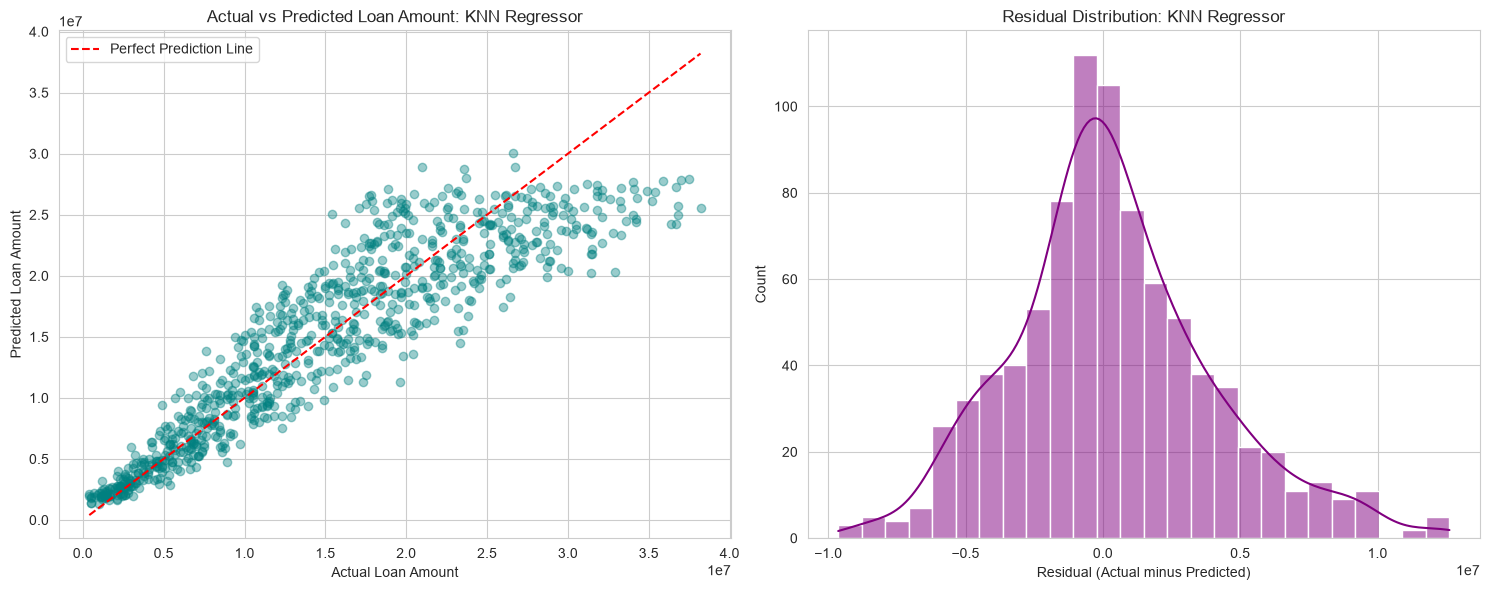

In [12]:
regression_predictions = best_knn_regressor.predict(X_test_reg_scaled)

r2 = r2_score(y_test_reg, regression_predictions)
mae = mean_absolute_error(y_test_reg, regression_predictions)
mse = mean_squared_error(y_test_reg, regression_predictions)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, regression_predictions)

print("KNN Regressor test set performance:")
print(f"  R2 Score : {r2:.4f}")
print(f"  MAE      : {mae:,.2f}")
print(f"  MSE      : {mse:,.2f}")
print(f"  RMSE     : {rmse:,.2f}")
print(f"  MAPE     : {mape:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test_reg, regression_predictions, alpha=0.4, color="teal")
min_value = min(y_test_reg.min(), regression_predictions.min())
max_value = max(y_test_reg.max(), regression_predictions.max())
axes[0].plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--", label="Perfect Prediction Line")
axes[0].set_xlabel("Actual Loan Amount")
axes[0].set_ylabel("Predicted Loan Amount")
axes[0].set_title("Actual vs Predicted Loan Amount: KNN Regressor")
axes[0].legend()

residuals = y_test_reg - regression_predictions
sns.histplot(residuals, kde=True, color="purple", ax=axes[1])
axes[1].set_title("Residual Distribution: KNN Regressor")
axes[1].set_xlabel("Residual (Actual minus Predicted)")

plt.tight_layout()
plt.show()

## Phase 13: Model Serialization and Deployment Artifact Export

Model persistence decouples this training notebook from the production inference pipeline
executed inside the accompanying Streamlit application, streamlit_app.py. Six artifacts are
required for correct and reproducible inference across both tasks addressed in this
notebook: the tuned KNN Classifier, the fitted Gaussian Naive Bayes classifier, and the
fitted StandardScaler and ordered feature column list used for the classification task, plus
the tuned KNN Regressor and the fitted StandardScaler and ordered feature column list used
for the regression task. The label encoder used to convert loan_status into a binary integer
is also exported, so that the Streamlit application can translate numeric predictions back
into the original Approved or Rejected labels. Robust directory creation logic ensures that
the models directory exists whether this notebook is executed from the notebooks directory
or from the project root.

In [13]:
import joblib

model_directory_candidates = [os.path.join("..", "models"), "models"]
MODEL_DIRECTORY = None
for candidate in model_directory_candidates:
    parent = os.path.dirname(candidate) or "."
    if os.path.isdir(parent) or candidate == "models":
        MODEL_DIRECTORY = candidate
        break

if MODEL_DIRECTORY is None:
    MODEL_DIRECTORY = "models"

os.makedirs(MODEL_DIRECTORY, exist_ok=True)
print("Model artifacts will be saved to:", os.path.abspath(MODEL_DIRECTORY))

# ---- Classification artifacts ----
joblib.dump(best_knn_classifier, os.path.join(MODEL_DIRECTORY, "knn_classifier_model.joblib"))
joblib.dump(naive_bayes_classifier, os.path.join(MODEL_DIRECTORY, "naive_bayes_classifier_model.joblib"))
joblib.dump(classification_scaler, os.path.join(MODEL_DIRECTORY, "classification_scaler.joblib"))
joblib.dump(classification_feature_columns, os.path.join(MODEL_DIRECTORY, "classification_feature_columns.joblib"))
joblib.dump(label_encoder, os.path.join(MODEL_DIRECTORY, "loan_status_label_encoder.joblib"))

# ---- Regression artifacts ----
joblib.dump(best_knn_regressor, os.path.join(MODEL_DIRECTORY, "knn_regressor_model.joblib"))
joblib.dump(regression_scaler, os.path.join(MODEL_DIRECTORY, "regression_scaler.joblib"))
joblib.dump(regression_feature_columns, os.path.join(MODEL_DIRECTORY, "regression_feature_columns.joblib"))

# ---- Combined metadata artifact ----
classification_metadata = {
    "classification_comparison_table": classification_comparison_df.to_dict(orient="records"),
    "best_classification_model_name": best_classification_model_name,
    "classification_feature_columns": classification_feature_columns,
    "regression_feature_columns": regression_feature_columns,
    "regression_metrics": {
        "r2": r2,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "mape": mape,
    },
}
joblib.dump(classification_metadata, os.path.join(MODEL_DIRECTORY, "model_metadata.joblib"))

print()
print("Saved artifacts:")
for artifact_file in sorted(os.listdir(MODEL_DIRECTORY)):
    print(" -", artifact_file)

Model artifacts will be saved to: c:\Users\soham\Desktop\ahmed\NTI-ML\05_KNN&NB_Loan_Approval\models

Saved artifacts:
 - classification_feature_columns.joblib
 - classification_scaler.joblib
 - knn_classifier_model.joblib
 - knn_regressor_model.joblib
 - loan_status_label_encoder.joblib
 - model_metadata.joblib
 - naive_bayes_classifier_model.joblib
 - regression_feature_columns.joblib
 - regression_scaler.joblib


## Phase 14: Conclusion

This notebook demonstrated two applications of K-Nearest Neighbors alongside one application
of Gaussian Naive Bayes, all on the same underlying loan approval dataset. For the
classification task, predicting loan_status, both algorithms were trained and evaluated on
an identical scaled feature matrix that retains loan_amount as a predictor, and their
accuracy, precision, recall, F1-score, and ROC-AUC scores were compared directly. For the
regression task, predicting loan_amount, K-Nearest Neighbors Regressor was trained on a
separate feature matrix that excludes loan_status to avoid target leakage, and evaluated
using R-squared alongside absolute and percentage error metrics. Gaussian Naive Bayes was
intentionally not applied to the regression task, since it is a classification algorithm
without a standard regression counterpart. All trained models, fitted scalers, feature
column schemas, and the label encoder have been serialized to the models directory in Phase
13, and are now ready to be consumed by the accompanying Streamlit application,
streamlit_app.py, which exposes an interactive interface for both the loan approval
classification task and the loan amount regression task.